# LLM Output Analysis
Exploratory comparison of LLM-generated data cleaning outputs against ground truth, across models and tasks.

## Setup
Set `TASK` and `MODELS` below, then run all cells. Put data dir in the .env file (NEXTSTEPS_DATA_DIR=dir)

## Load Data and packages

In [11]:
import subprocess, sys
for pkg in ['pandas', 'numpy', 'matplotlib', 'seaborn', 'python-dotenv']:
    try:
        __import__(pkg.replace('-', '_').split('.')[0])
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg],
                              stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()
BASE_DIR = Path(os.environ['NEXTSTEPS_DATA_DIR'])

# Set task and models to compare
TASK   = 18
MODELS = ['qwen3.5_9b', 'devstral', 'qwen3.5_397']

In [12]:
# Load ground truth and LLM prediction for each model
id_col = 'NSID'
data = {}

for model in MODELS:
    matches = list((BASE_DIR / model).glob(f'sample{TASK}_*'))
    assert len(matches) == 1, f'{model}: expected 1 match, found {len(matches)}'
    out_dir = matches[0] / 'data' / 'output'

    gt   = pd.read_csv(out_dir / 'output.csv')
    pred = pd.read_csv(out_dir / 'cleaned_data.csv')

    shared = [c for c in gt.columns if c in pred.columns and c != id_col]
    merged = gt.merge(pred, on=id_col, suffixes=('_gt', '_pred'))

    data[model] = {'gt': gt, 'pred': pred, 'merged': merged, 'shared_cols': shared}
    print(f'{model}: {len(shared)} shared columns -> {shared}')

all_shared = set.intersection(*(set(v['shared_cols']) for v in data.values()))
print(f'\nColumns in all models: {sorted(all_shared)}')

qwen3.5_9b: 8 shared columns -> ['ghq15', 'ghq17', 'ghq25', 'ghq32', 'ghqtl15', 'ghqtl17', 'ghqtl25', 'ghqtl32']
devstral: 8 shared columns -> ['ghq15', 'ghq17', 'ghq25', 'ghq32', 'ghqtl15', 'ghqtl17', 'ghqtl25', 'ghqtl32']
qwen3.5_397: 8 shared columns -> ['ghq15', 'ghq17', 'ghq25', 'ghq32', 'ghqtl15', 'ghqtl17', 'ghqtl25', 'ghqtl32']

Columns in all models: ['ghq15', 'ghq17', 'ghq25', 'ghq32', 'ghqtl15', 'ghqtl17', 'ghqtl25', 'ghqtl32']


## Cross-tabulation Plots
Each plot shows ground truth (rows) vs LLM prediction (cols). Blue = match, orange = mismatch.

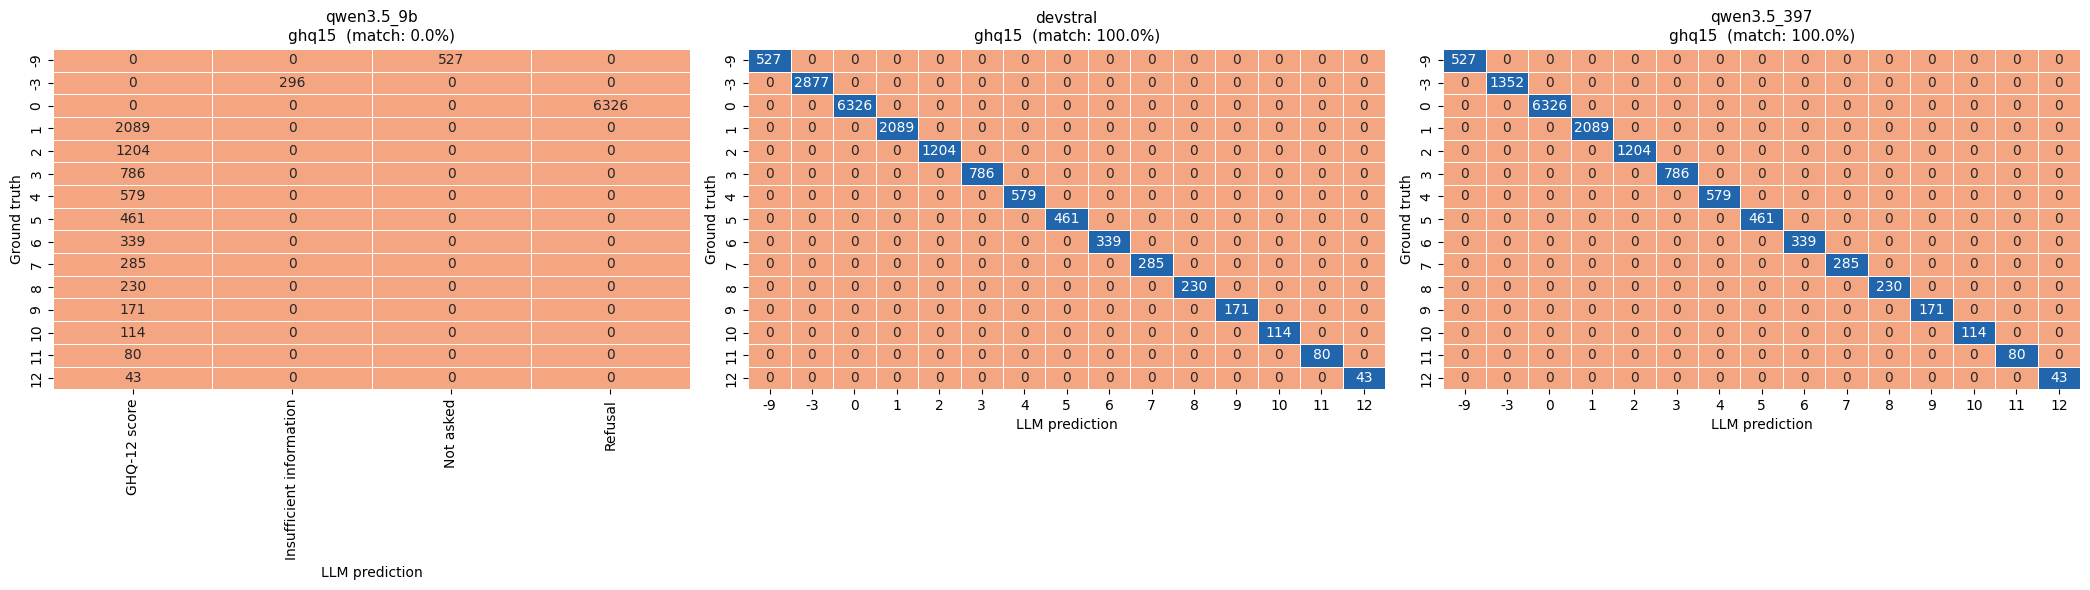

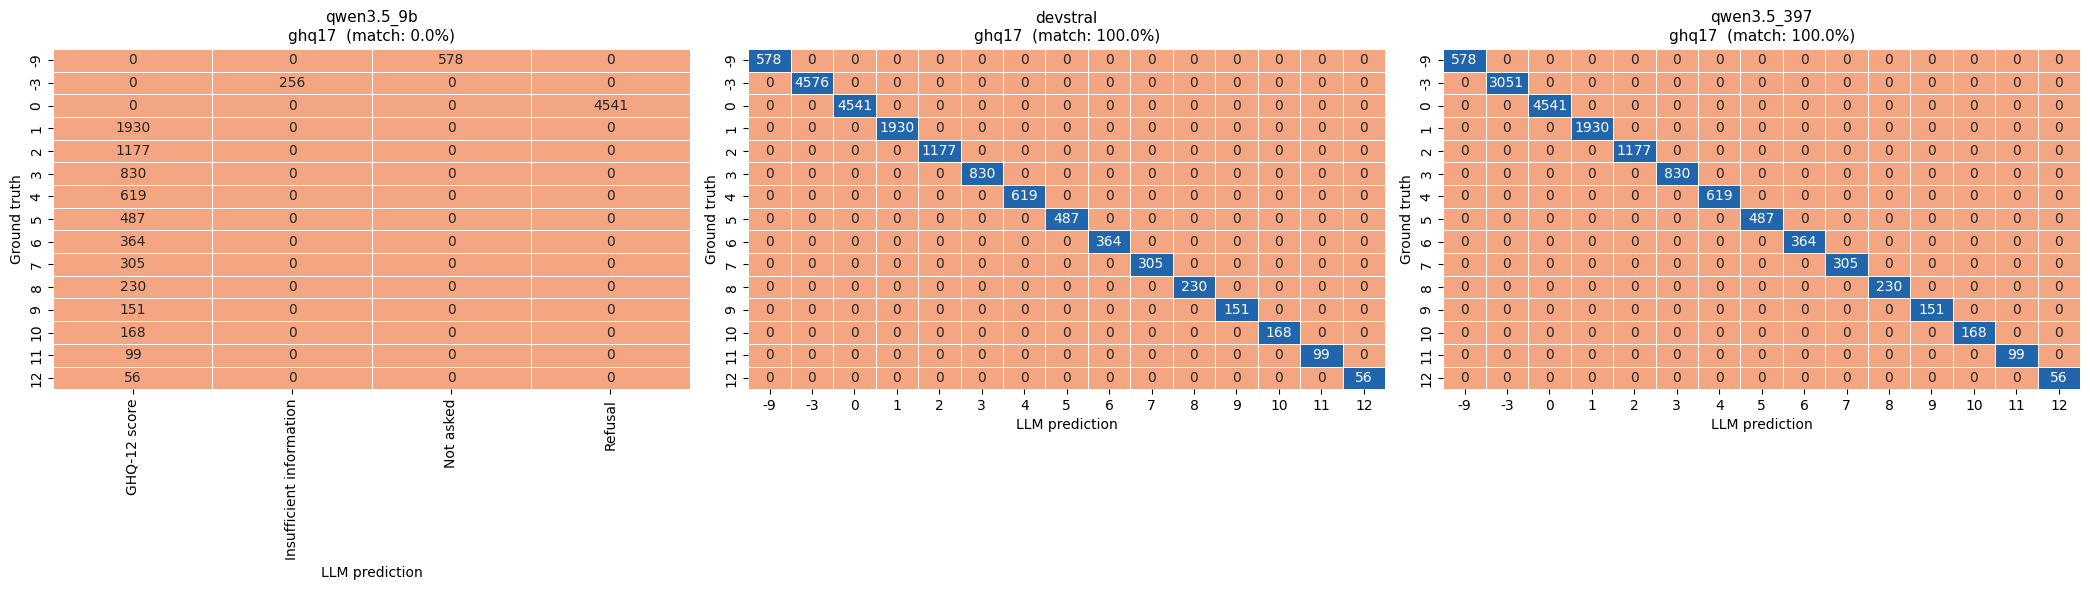

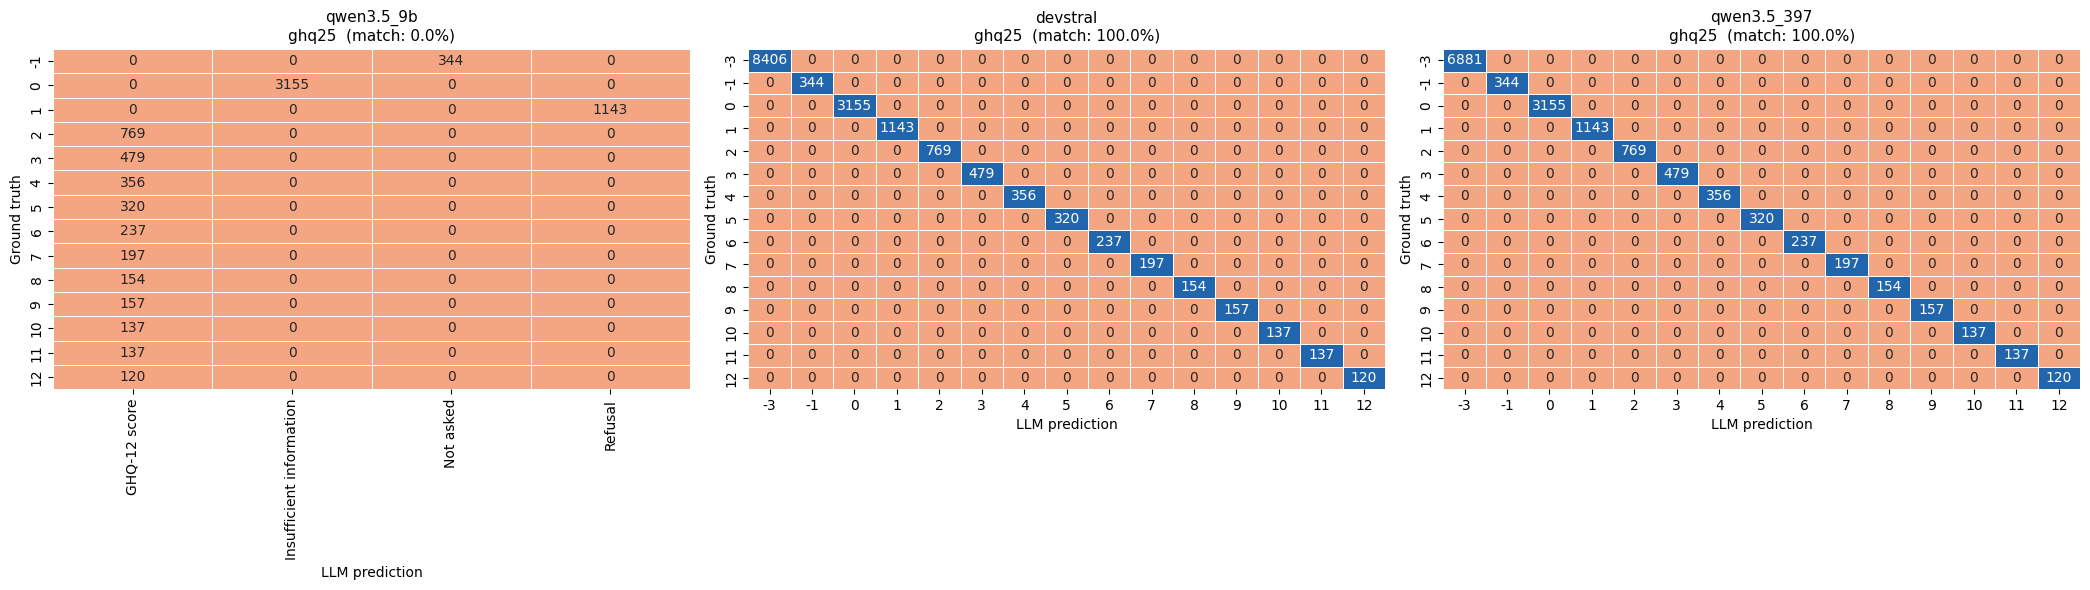

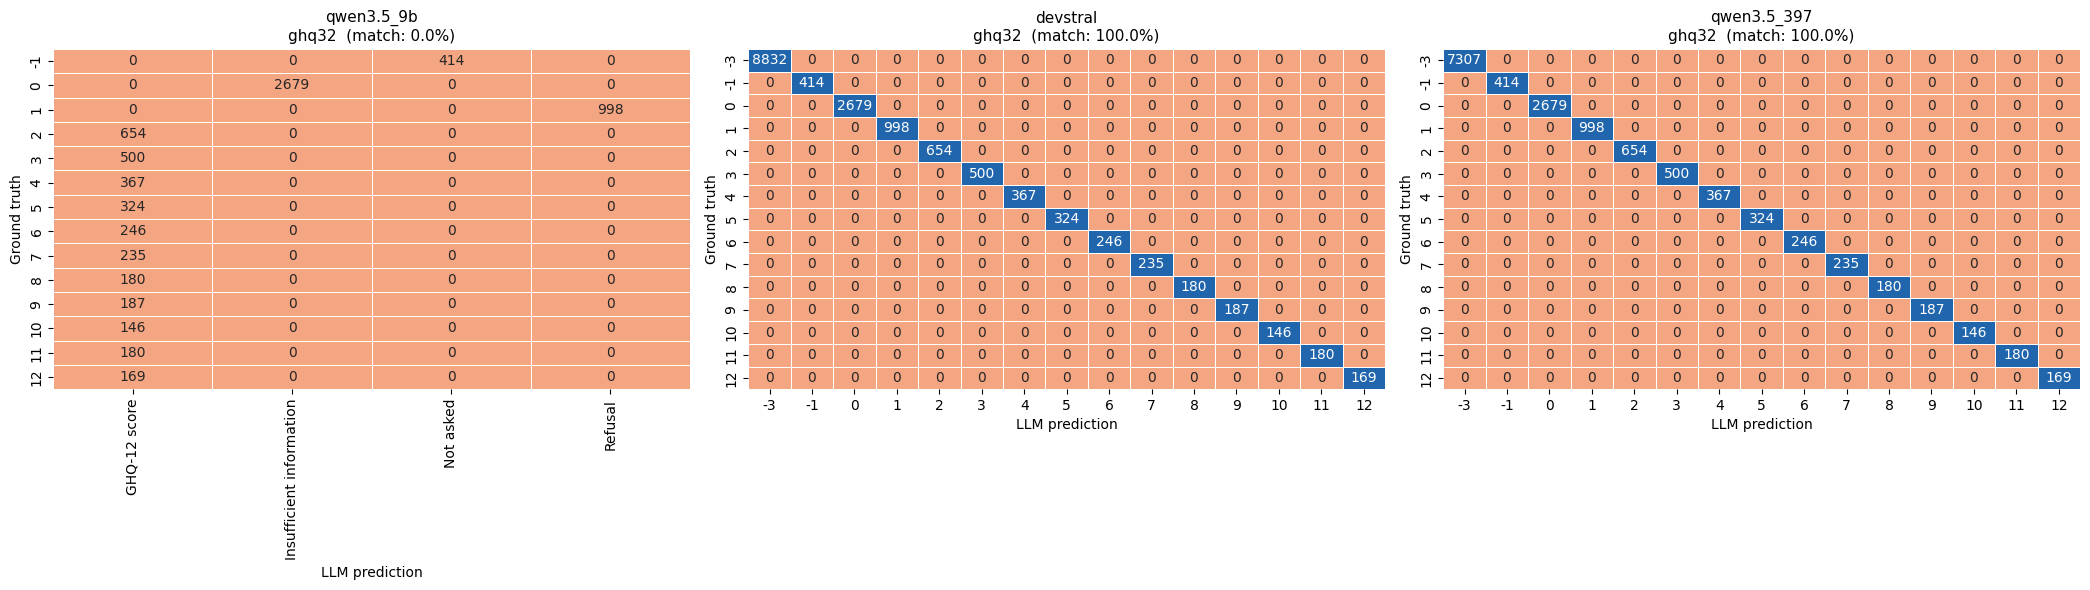

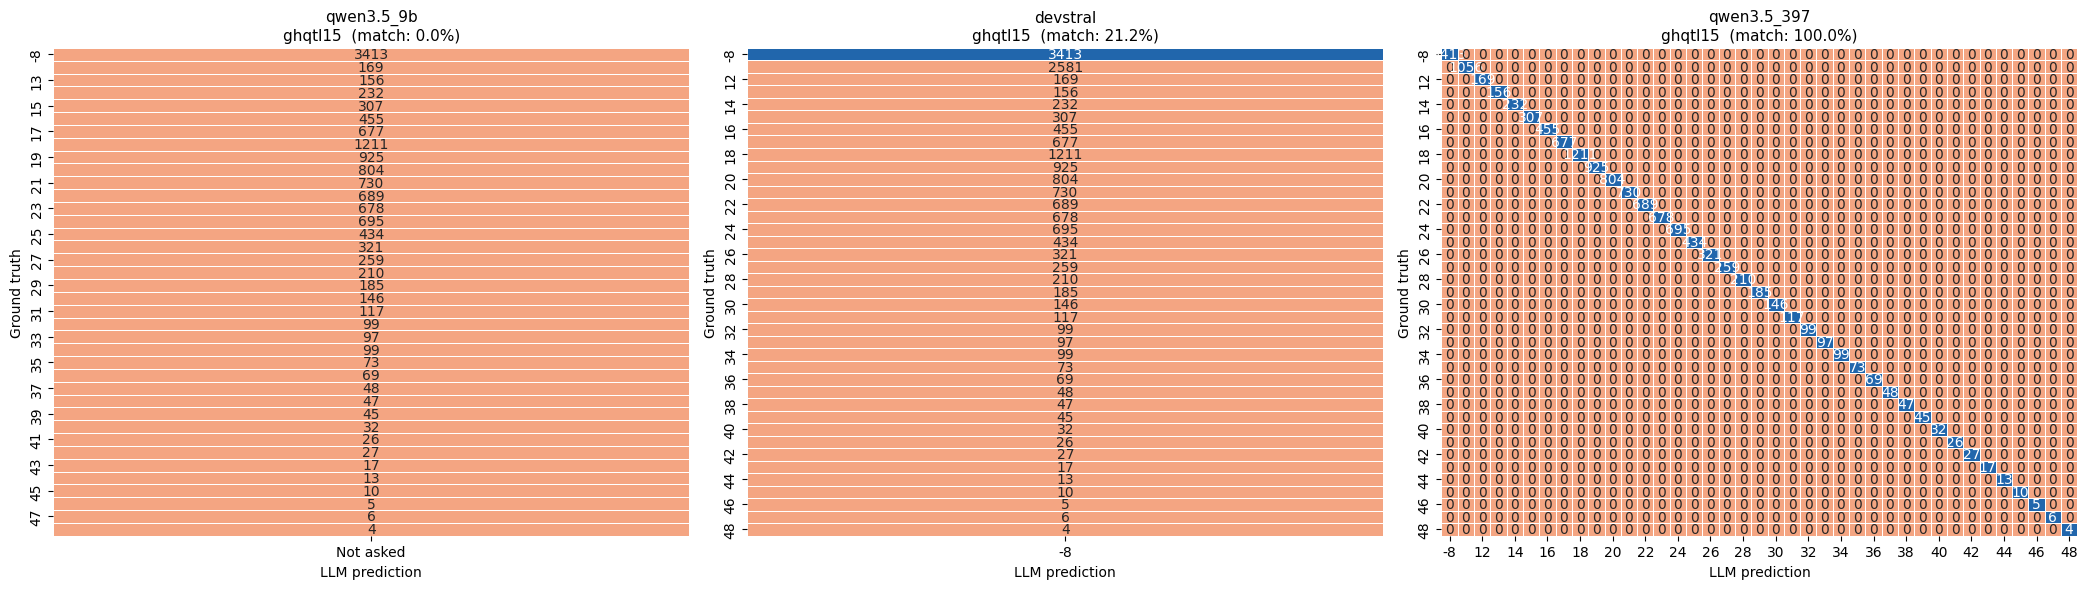

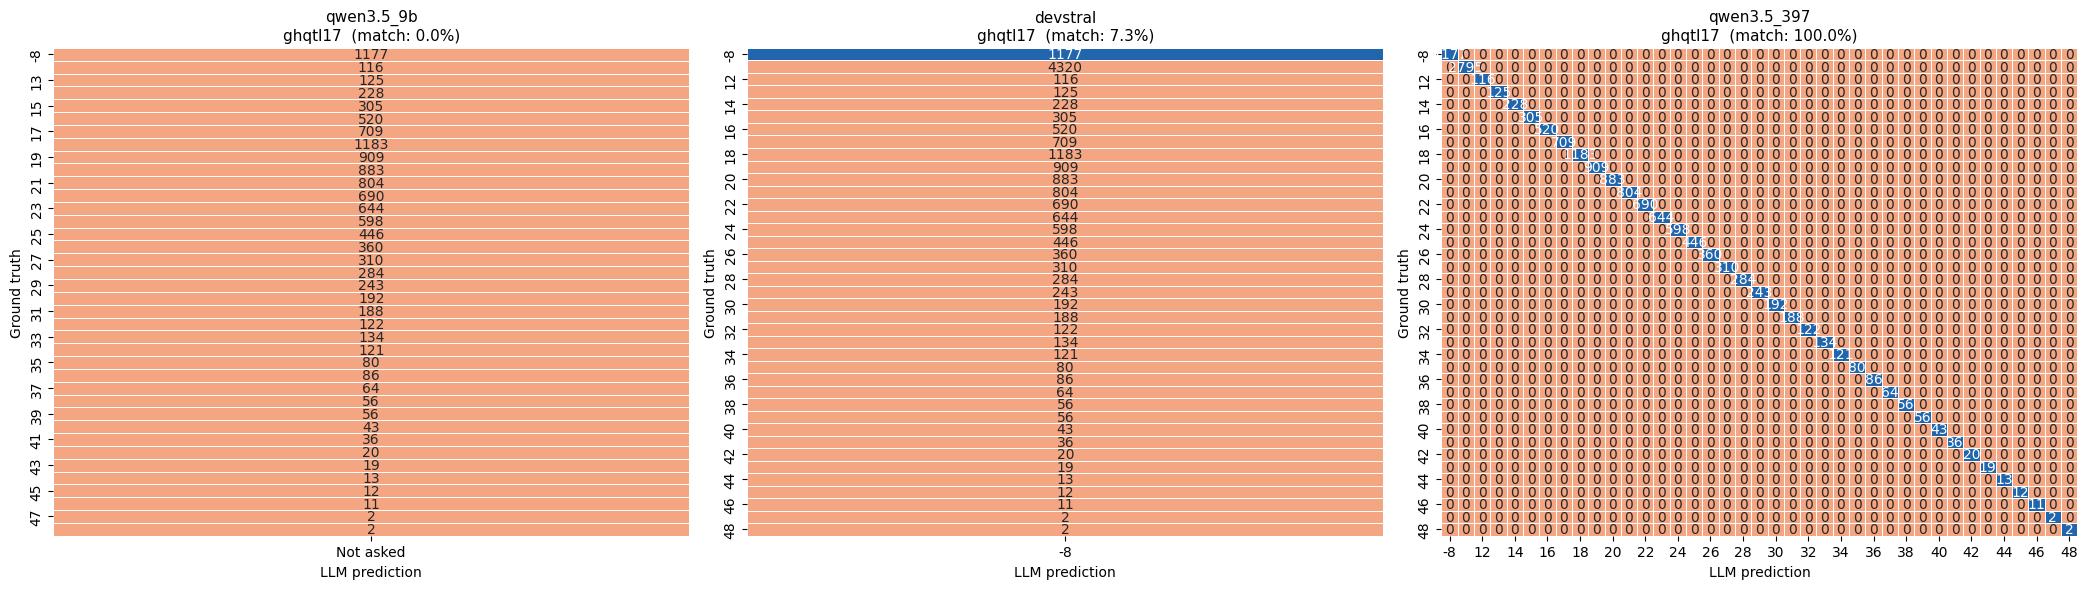

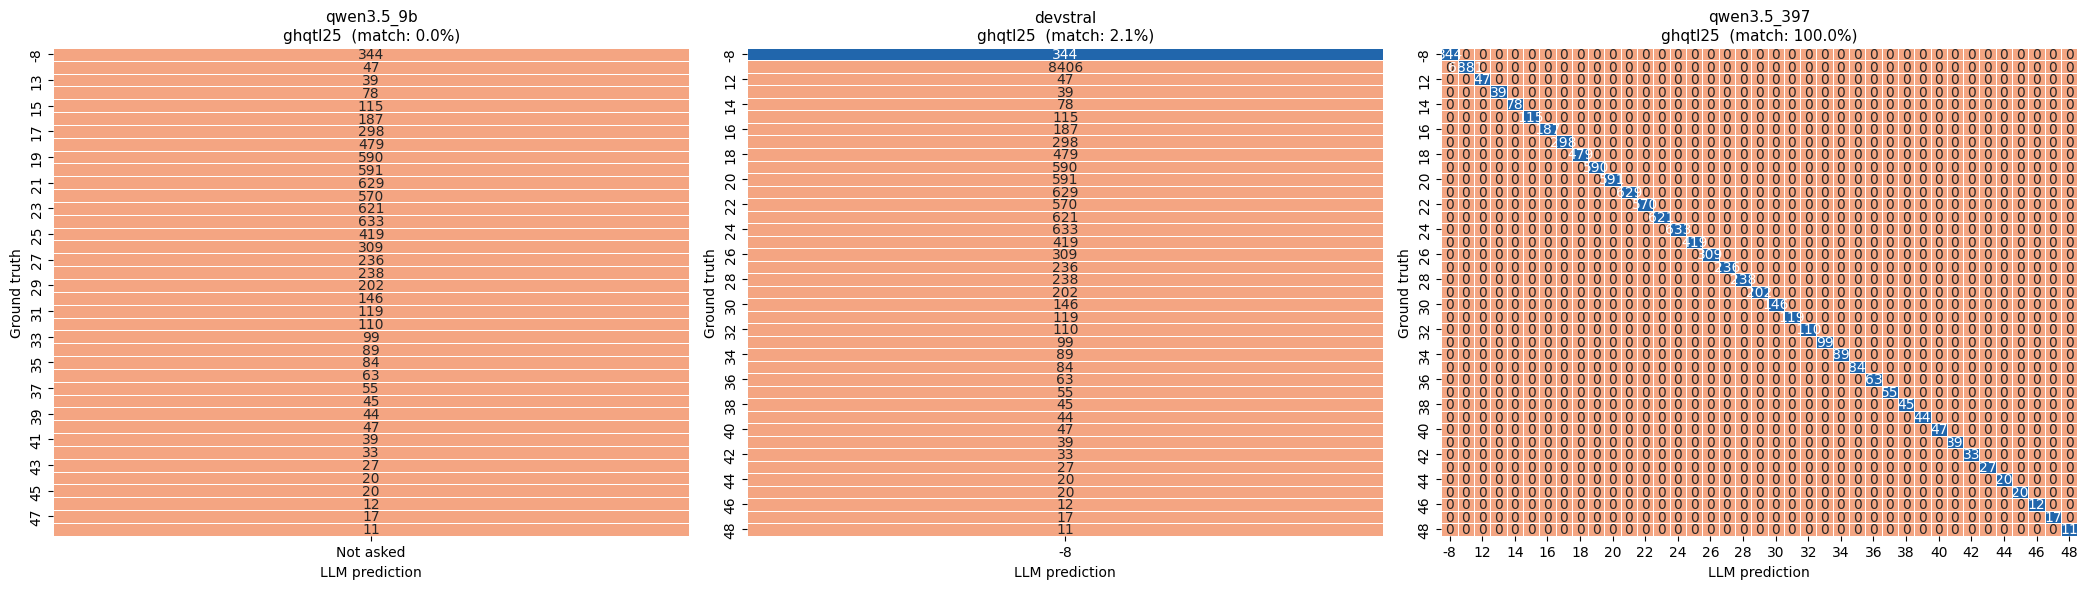

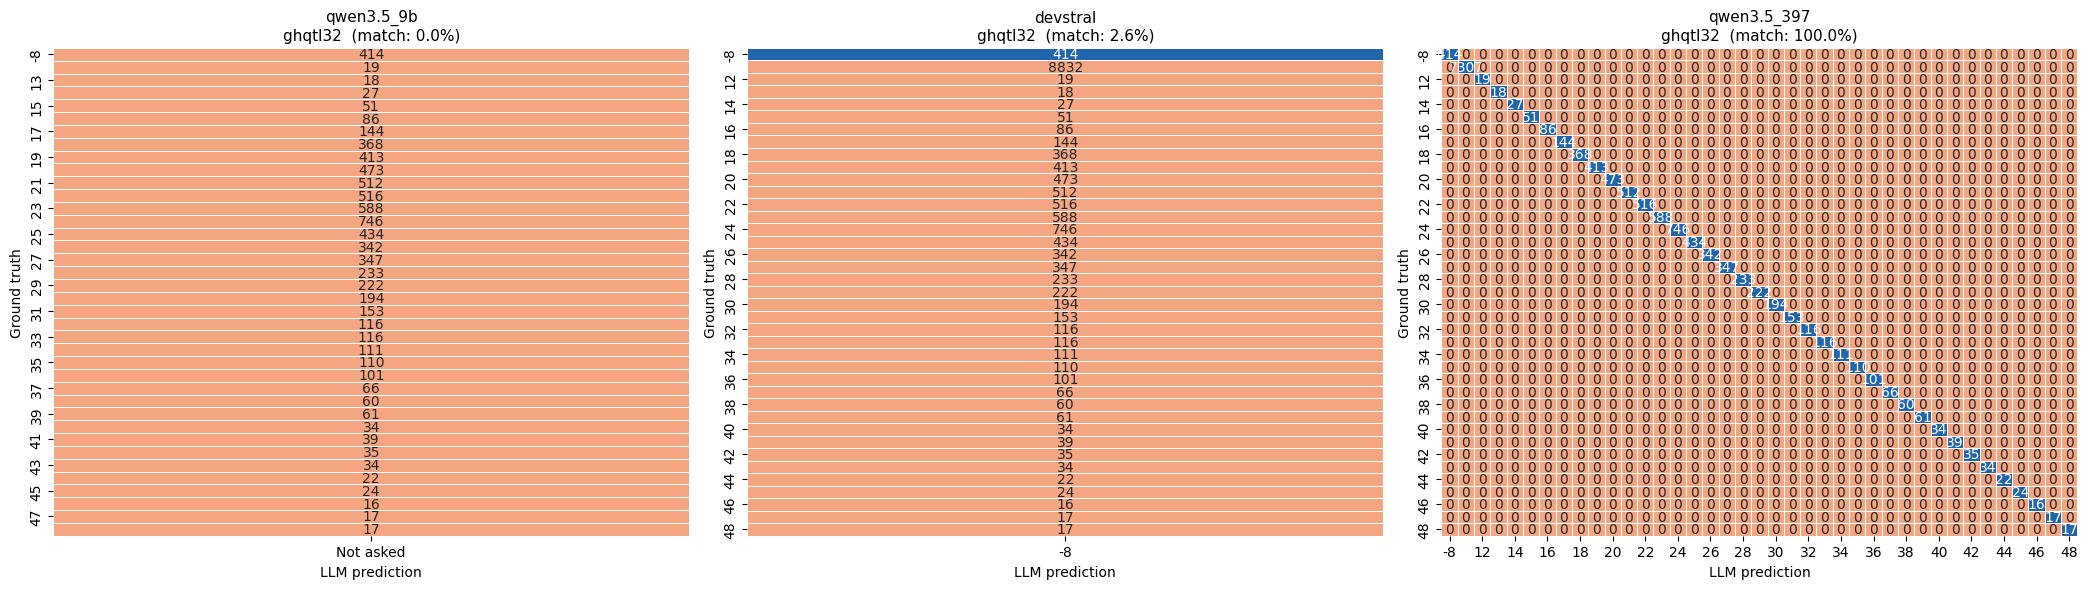

In [13]:
# Side-by-side heatmaps per variable, one column per model
cmap = ListedColormap(['#f4a582', '#2166ac'])  # orange = mismatch, blue = match

for col in sorted(all_shared):
    fig, axes = plt.subplots(1, len(MODELS), figsize=(7 * len(MODELS), 6))
    if len(MODELS) == 1:
        axes = [axes]

    for ax, model in zip(axes, MODELS):
        merged = data[model]['merged']
        gt_col, pred_col = f'{col}_gt', f'{col}_pred'

        ct = pd.crosstab(merged[gt_col], merged[pred_col], margins=False)
        diag = pd.DataFrame(0, index=ct.index, columns=ct.columns)
        for val in ct.index:
            if val in ct.columns:
                diag.loc[val, val] = 1

        sns.heatmap(diag, annot=ct, fmt='d', cmap=cmap, vmin=0, vmax=1,
                    linewidths=0.5, cbar=False, ax=ax)

        match_rate = (merged[gt_col] == merged[pred_col]).mean()
        ax.set_title(f'{model}\n{col}  (match: {match_rate:.1%})', fontsize=11)
        ax.set_xlabel('LLM prediction')
        ax.set_ylabel('Ground truth')

    plt.tight_layout()
    plt.show()